In [211]:
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import yaml
import os.path as op
import scanpy as sc
import numpy as np
import pandas as pd




In [212]:


def read_all_results(root_dir, select = ('overlaps_global_top_k_quantile_count.tsv')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(select) and filename == select:

                filepath = os.path.join(dirpath, filename)
                print(filepath)
                try:
                    overlaps = pd.read_csv(filepath, sep = '\t')
                    overlaps['net'] = op.basename(op.dirname(filepath))
                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results

In [282]:


def read_all_results2(root_dir, select = ('overlaps_global_top_k_quantile_count.tsv')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(select) and filename == 'preclustered_overlaps_global_top_k.tsv':

                filepath = os.path.join(dirpath, filename)
                print(filepath)
                try:
                    overlaps = pd.read_csv(filepath, sep = '\t', index_col=0)
                    overlaps['net'] = op.basename(op.dirname(filepath))
                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results

In [283]:
all_overlaps = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/', select=('overlaps_global_top_k_tf.tsv'))
grnb = read_all_results2('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/', select=('overlaps_global_top_k.tsv'))
scgenerai = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/', select=('overlaps_global_top_k_averaged.tsv'))



/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_70_11431_net_60_10082_net_135_11054_net_53_11196/overlaps_global_top_k_tf.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_70_11431_net_84_9903_net_59_10488_net_115_11153/overlaps_global_top_k_tf.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_84_11226_net_172_10626_net_89_11634_net_76_10367/overlaps_global_top_k_tf.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_60_10082_net_64_11307_net_84_11226_net_133_10773/overlaps_global_top_k_tf.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_82_10152_net_72_10551_net_98_11932_net_51_10906/overlaps_global_top_k_tf.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_three/net_60_10082_net_90_11013_net_75_10306_net_77_11506/overlaps_global_top_k_tf.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries

In [284]:
grnb

,n_top,percentage_recovered,tp,gs_count,pp,type,grn,net
0,94,0.000000,0,88,94,on_target,0,net_70_11431_net_60_10082_net_135_11054_net_53...
1,945,0.022727,2,88,945,on_target,0,net_70_11431_net_60_10082_net_135_11054_net_53...
2,4723,0.125000,11,88,4723,on_target,0,net_70_11431_net_60_10082_net_135_11054_net_53...
3,9445,0.204545,18,88,9445,on_target,0,net_70_11431_net_60_10082_net_135_11054_net_53...
4,18890,0.329545,29,88,18890,on_target,0,net_70_11431_net_60_10082_net_135_11054_net_53...
...,...,...,...,...,...,...,...,...
4,22456,0.243386,46,189,22456,on_target,2,net_75_10306_net_115_11153_net_72_10551_net_11...
5,28070,0.269841,51,189,28070,on_target,2,net_75_10306_net_115_11153_net_72_10551_net_11...
6,56140,0.317460,60,189,37631,on_target,2,net_75_10306_net_115_11153_net_72_10551_net_11...
7,84209,0.317460,60,189,37631,on_target,2,net_75_10306_net_115_11153_net_72_10551_net_11...


In [285]:
# For counting, the number of edges has been doubled (forward-backward) therefore, divide by 2 to adjust.
scgenerai['gold_standard_edges'] = scgenerai['gold_standard_edges']/2

In [286]:
grnb['top_perc'] = np.tile([0.001,0.01, 0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 1.0], reps = int(grnb.shape[0]/9))
grnb = grnb.loc[: ,['top_perc', 'percentage_recovered', 'type']]
grnb['method']  = 'grnboost'
grnb.columns =  ['n_top', 'percentage_overlap',  'type',  'configuration']

In [287]:
grnb

,n_top,percentage_overlap,type,configuration
0,0.001,0.000000,on_target,grnboost
1,0.010,0.022727,on_target,grnboost
2,0.050,0.125000,on_target,grnboost
3,0.100,0.204545,on_target,grnboost
4,0.200,0.329545,on_target,grnboost
...,...,...,...,...
4,0.200,0.243386,on_target,grnboost
5,0.250,0.269841,on_target,grnboost
6,0.500,0.317460,on_target,grnboost
7,0.750,0.317460,on_target,grnboost


In [288]:
scgenerai = process_results(scgenerai)
all_overlaps = process_results(all_overlaps)

In [289]:
def process_results(all_overlaps):
    all_overlaps['configuration'] = all_overlaps['method']+'_'+all_overlaps['layer']
    all_overlaps['factor'] = all_overlaps['mean_cell_count']/500
    all_overlaps['factor'] = all_overlaps['factor'].apply(lambda x: min(1, x))
    all_overlaps['weighted_overlap'] = all_overlaps['avg_edges_recovered']*(all_overlaps['factor'])

    all_overlaps = all_overlaps[~all_overlaps.avg_edges_recovered.isna()]
    all_overlaps = all_overlaps[~all_overlaps.mean_cell_count.isna()]
    all_overlaps['percentage_overlap'] = all_overlaps['weighted_overlap']/all_overlaps['gold_standard_edges']

    all_overlaps['precision'] = all_overlaps['weighted_overlap']/(all_overlaps['avg_edges_recovered'] + (all_overlaps['max_possible_edges']*all_overlaps['n_top']))
    return all_overlaps

In [ ]:
grnb_sub = grnb.loc[grnb.type == 'on_target', :]
grnb_sub = grnb_sub.loc[:,  ['n_top', 'percentage_overlap', 'configuration']]

all_overlaps_sub  = all_overlaps.loc[(all_overlaps.target == 'on_target') & (all_overlaps.net_type=='strict') & (all_overlaps.direction=='forward') & (all_overlaps.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration']]
scgenerai_sub =scgenerai.loc[(scgenerai.target == 'on_target') & (scgenerai.net_type=='strict') & (scgenerai.direction=='forward'), ['n_top', 'percentage_overlap',  'configuration']]
data = pd.concat([grnb_sub, all_overlaps_sub, scgenerai_sub], ignore_index=True)



,n_top,percentage_overlap,configuration
0,0.001,0.000000,grnboost
1,0.010,0.022727,grnboost
2,0.050,0.125000,grnboost
3,0.100,0.204545,grnboost
4,0.200,0.329545,grnboost
...,...,...,...
2735,0.200,0.214952,scgenerai_config_X
2736,0.250,0.266360,scgenerai_config_X
2737,0.500,0.520466,scgenerai_config_X
2738,0.750,0.763587,scgenerai_config_X


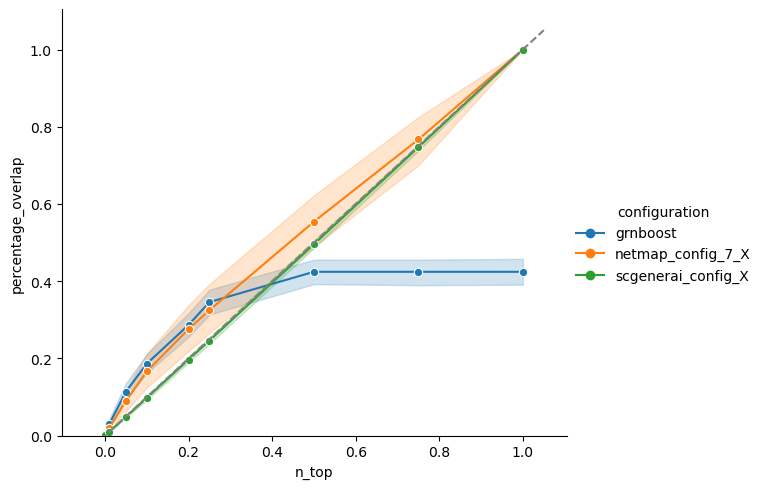

<Figure size 640x480 with 0 Axes>

In [293]:

# 3. Use sns.relplot with 'col' for faceting
g = sns.relplot(
    data=data[data.configuration.isin(['netmap_config_7_X', 'scgenerai_config_X', 'grnboost'])], # Use the filtered data
    hue='configuration',
    x='n_top',
    y='percentage_overlap',
    kind='line',
    marker='o',
    height=5, # Height of each facet (in inches)
    aspect=1.2 # Aspect ratio of each facet (width/height)
)

for ax in g.axes.flat:
    # Get current x limits for this facet
    xlim = ax.get_xlim()
    # Define line coordinates
    x = np.linspace(xlim[0], xlim[1], 100)
    y = x  # slope = 1, intercept = 0
    
    # Plot the line
    ax.plot(x, y, color='gray', linestyle='--', linewidth=1.5, label='Random (y = x)')
    
    # Optionally adjust y-limits to show the full line
    ax.set_ylim(0, max(ax.get_ylim()[1], xlim[1]))

# Add a shared legend
handles, labels = g.axes[0,0].get_legend_handles_labels()
if 'Random (y = x)' not in labels:
    handles.append(plt.Line2D([], [], color='gray', linestyle='--', label='Random (y = x)'))
    labels.append('Random (y = x)')
    g._legend.remove()
    g.fig.legend(handles, labels, loc='upper center', ncol=3)


plt.show()
# 4. Customizations
g.figure.suptitle('On cluster edges by Facet Variable', y=1.03) # Main title for the entire figure
g.set_axis_labels('#top edges', 'Percentage overlap') # Set axis labels for all facets
g.set_titles(col_template="{col_name}") # Customize the title above each panel (optional)
plt.tight_layout()
plt.show()

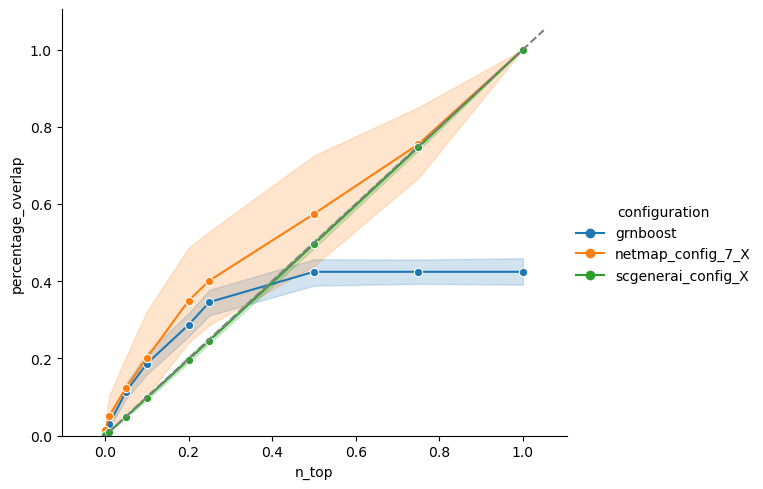

<Figure size 640x480 with 0 Axes>

In [300]:
grnb_sub = grnb.loc[grnb.type == 'on_target', :]
grnb_sub = grnb_sub.loc[:,  ['n_top', 'percentage_overlap', 'configuration']]

all_overlaps_sub  = all_overlaps.loc[(all_overlaps.target == 'on_target') & (all_overlaps.net_type=='unspecific') & (all_overlaps.direction=='forward') & (all_overlaps.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration']]
scgenerai_sub =scgenerai.loc[(scgenerai.target == 'on_target') & (scgenerai.net_type=='strict') & (scgenerai.direction=='forward'), ['n_top', 'percentage_overlap',  'configuration']]
data = pd.concat([grnb_sub, all_overlaps_sub, scgenerai_sub], ignore_index=True)


# 3. Use sns.relplot with 'col' for faceting
g = sns.relplot(
    data=data[data.configuration.isin(['netmap_config_7_X', 'scgenerai_config_X', 'grnboost'])], # Use the filtered data
    hue='configuration',
    x='n_top',
    y='percentage_overlap',
    kind='line',
    marker='o',
    height=5, # Height of each facet (in inches)
    aspect=1.2 # Aspect ratio of each facet (width/height)
)

for ax in g.axes.flat:
    # Get current x limits for this facet
    xlim = ax.get_xlim()
    # Define line coordinates
    x = np.linspace(xlim[0], xlim[1], 100)
    y = x  # slope = 1, intercept = 0
    
    # Plot the line
    ax.plot(x, y, color='gray', linestyle='--', linewidth=1.5, label='Random (y = x)')
    
    # Optionally adjust y-limits to show the full line
    ax.set_ylim(0, max(ax.get_ylim()[1], xlim[1]))

# Add a shared legend
handles, labels = g.axes[0,0].get_legend_handles_labels()
if 'Random (y = x)' not in labels:
    handles.append(plt.Line2D([], [], color='gray', linestyle='--', label='Random (y = x)'))
    labels.append('Random (y = x)')
    g._legend.remove()
    g.fig.legend(handles, labels, loc='upper center', ncol=3)


plt.show()
# 4. Customizations
g.figure.suptitle('On cluster edges by Facet Variable', y=1.03) # Main title for the entire figure
g.set_axis_labels('#top edges', 'Percentage overlap') # Set axis labels for all facets
g.set_titles(col_template="{col_name}") # Customize the title above each panel (optional)
plt.tight_layout()
plt.show()

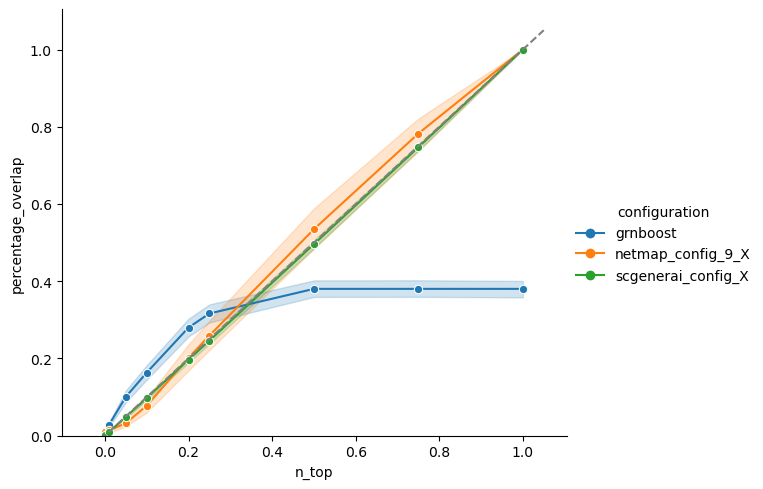

<Figure size 640x480 with 0 Axes>

In [296]:
grnb_sub = grnb.loc[grnb.type == 'off_target', :]
grnb_sub = grnb_sub.loc[:,  ['n_top', 'percentage_overlap', 'configuration']]

all_overlaps_sub  = all_overlaps.loc[(all_overlaps.target == 'off_target') & (all_overlaps.net_type=='strict') & (all_overlaps.direction=='forward') & (all_overlaps.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration']]
scgenerai_sub =scgenerai.loc[(scgenerai.target == 'on_target') & (scgenerai.net_type=='strict') & (scgenerai.direction=='forward'), ['n_top', 'percentage_overlap',  'configuration']]
data = pd.concat([grnb_sub, all_overlaps_sub, scgenerai_sub], ignore_index=True)


# 3. Use sns.relplot with 'col' for faceting
g = sns.relplot(
    data=data[data.configuration.isin(['netmap_config_9_X', 'scgenerai_config_X', 'grnboost'])], # Use the filtered data
    hue='configuration',
    x='n_top',
    y='percentage_overlap',
    kind='line',
    marker='o',
    height=5, # Height of each facet (in inches)
    aspect=1.2 # Aspect ratio of each facet (width/height)
)

for ax in g.axes.flat:
    # Get current x limits for this facet
    xlim = ax.get_xlim()
    # Define line coordinates
    x = np.linspace(xlim[0], xlim[1], 100)
    y = x  # slope = 1, intercept = 0
    
    # Plot the line
    ax.plot(x, y, color='gray', linestyle='--', linewidth=1.5, label='Random (y = x)')
    
    # Optionally adjust y-limits to show the full line
    ax.set_ylim(0, max(ax.get_ylim()[1], xlim[1]))

# Add a shared legend
handles, labels = g.axes[0,0].get_legend_handles_labels()
if 'Random (y = x)' not in labels:
    handles.append(plt.Line2D([], [], color='gray', linestyle='--', label='Random (y = x)'))
    labels.append('Random (y = x)')
    g._legend.remove()
    g.fig.legend(handles, labels, loc='upper center', ncol=3)


plt.show()
# 4. Customizations
g.figure.suptitle('On cluster edges by Facet Variable', y=1.03) # Main title for the entire figure
g.set_axis_labels('#top edges', 'Percentage overlap') # Set axis labels for all facets
g.set_titles(col_template="{col_name}") # Customize the title above each panel (optional)
plt.tight_layout()
plt.show()